### Objetivos do Notebook

Notebook reponsável por extrair a tabela de origem ssi_fato_realizacao_asos do datamart de SSI  armazenadas no sistema S+ e salvar esses dados no formato Parquet no bucket bronze do MinIO.

### Data Owner
Rodrigo Souza - rodrigo.souza@sfiemt.ind.br

### Horário de execução do Notebook
Não executado



### Origens extraídas do S+
As seguintes tabelas serão extraídas do sistema S+:

- **ssi_fato_realizacao_asos**

### Local de destino no bucket bronze
Os datasets resultantes gerados pela extração do notebook serão armazenados no bucket bronze do MinIO no formato Parquet, seguindo a estrutura de diretórios e nomes de arquivos baseados na data de execução do notebook.

- **ssi_fato_realizacao_asos:** bronze/ssi/smais/ssi_fato_realizacao_asos/{data_execucao}/ssi_fato_realizacao_asos_{data_execucao}.parquet

### Linhagem de dados
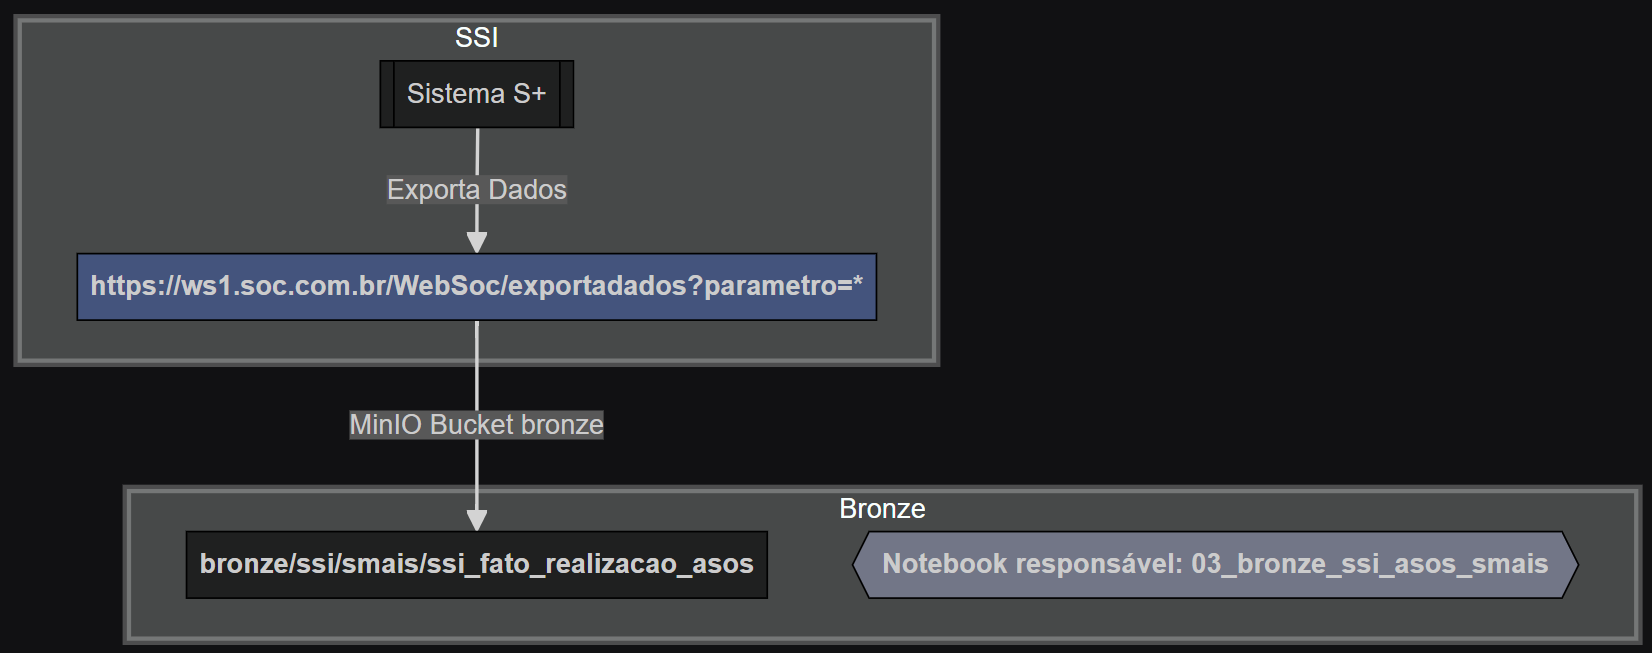

# Bibliotecas necessárias 

In [1]:
# import os
# import warnings
# import pandas as pd
# from datetime import datetime, timedelta
# from util.SSICalendarios import calendario_meses
# from util.SSIExportas import Exporta
# from util.SSIUtils import get_df_unidade, insert_datalake #Realiza leitura do csv em /tmp
# import json

# warnings.filterwarnings("ignore")

# Definição do período de busca na API

In [2]:
# Gera calendario automaticamente
# def gerar_calendario(dias):
#     # Calcular a data de fim (hoje)
#     data_fim = datetime.now()
    
#     # Calcular a data de início
#     data_inicio = data_fim - timedelta(days=dias-1)
    
#     return {'1': {'dataInicio': data_inicio.strftime("%d/%m/%Y"), 
#                   'dataFim': data_fim.strftime("%d/%m/%Y")}}

# # Gerar calendário com os últimos dias
# calendario = gerar_calendario(5)

# calendario = calendario_meses

# Obtendo credenciais da API para ASOs

In [3]:
# # Converter a string JSON em uma lista de Python
# cadastro_empresas_credentials = os.getenv('ASOS_CREDENTIALS')
# exporta_credentials = json.loads(cadastro_empresas_credentials)

# Realizando buscas na API para cada empresa em cada unidade

In [1]:
# frames = []
# for exporta in exporta_credentials:
#         #Retorna unidade da lista exporta_configs
#         unidade = exporta["unidade"]
#         #Retorna cod_exporta da lista exporta_configs
#         cod_exporta = exporta["cod_exporta"]
#         # Retorna chave_exporta da lista exporta_configs
#         chave_exporta = exporta["chave_exporta"]

#         # Instancia função Exporta (passando unidade, codigo, chave)
#         EXPORTA = Exporta(unidade=unidade, codigo=cod_exporta, chave=chave_exporta)
#         #data inicio
#         data_inicio = datetime.today() - timedelta(days=1)
#         data_inicio = data_inicio.strftime("%d/%m/%Y")
    
#         UNIDADE = EXPORTA.asos_no_periodo(dt_inicio=data_inicio)

#         # Chama função get_df_unidade de utils. Obtém um DataFrame com as informações da unidade vinculada especificada. (tmp/empresas.csv).Filtrando pelas unidades especificadas em exporta_credentials (cadastro_de_epi_credentials)
#         df_unidade = get_df_unidade(unidade_vinculada=unidade)

    
#         for m in calendario.keys():
#             # Calcular valores que não mudam no loop
#             calendario_value = calendario.get(m)
#             count_empresas = len(df_unidade)

#             UNIDADE.update_args(calendario_value)

#             for count, empresa in enumerate(df_unidade["CODIGO"]):
#                 print(f"Coletando empresa {empresa} da unidade {unidade}, {calendario_value} : {count}/{count_empresas}")
#                 UNIDADE.update_args({"empresa": empresa})

#                 df = UNIDADE.get_df({"UNIDADEVINCULADA": unidade, "CODIGOEMPRESA": empresa})

#                 if not df.empty or "<html>" not in df.columns:
#                      frames.append(df)


# Tratamento

In [ ]:
# Junção dos frames para geração de dataframe final
# df = pd.concat(frames)

In [ ]:
# Remoção de dados duplicados 
# df.drop_duplicates(inplace=True)

In [ ]:
# Aplica uma função lambda a todas as colunas do DataFrame, exceto nas colunas a ignorar
#df = df.apply(lambda col: col.str.replace(r'\t', '') if col.name and col.dtype == 'object' else col)

# Inserindo no Data Lake

In [ ]:
#insert_datalake(df, 'ssi_fato_realizacao_asos')